# Research Companion 01 · Version 2
## Same Size, Similar Performance… Same Learning?

**Roberto Casado Vara · BISITE Research Group · University of Salamanca**

This notebook compares two Variational Quantum Circuits with identical visible architectural counts.  
The comparison is repeated across several initializations, and internal quantities are evaluated at **validation-matched checkpoints**.

> **Can two VQCs exhibit comparable predictive performance while generating different gradient dynamics and representation geometries?**

The experiment uses exact local statevector simulation. It is a reproducible diagnostic, not evidence of a general theorem.

### Setup

Python 3.10 or newer is recommended. The notebook targets **Qiskit 2.5.1**.  
Exact gradients and repeated seeds may require a few minutes on a standard laptop.

In [ ]:
%pip install -q "qiskit==2.5.1" scikit-learn matplotlib pandas pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
from dataclasses import dataclass
from typing import Sequence
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7.5, 4.5), "figure.dpi": 120})

print("Qiskit:", qiskit.__version__)

Qiskit: 2.5.1


## 1. Controlled experimental setting

In [ ]:
DATA_SEED = 12
INITIALIZATION_SEEDS = (21, 34, 55, 89, 144)

N_SAMPLES = 96
N_QUBITS = 3
N_LAYERS = 2
STEPS = 30
LEARNING_RATE = 0.08

MIN_MATCH_STEP = 8
MIN_MATCH_ACCURACY = 0.65
LOSS_GAP_WEIGHT = 2.0

X_raw, y = make_moons(
    n_samples=N_SAMPLES,
    noise=0.12,
    random_state=DATA_SEED,
)

X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X_raw,
    y,
    test_size=1 / 3,
    random_state=DATA_SEED,
    stratify=y,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_holdout_raw,
    y_holdout,
    test_size=0.5,
    random_state=DATA_SEED,
    stratify=y_holdout,
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Initializations:    {len(INITIALIZATION_SEEDS)}")

Training samples:   64
Validation samples: 16
Test samples:       16
Initializations:    5


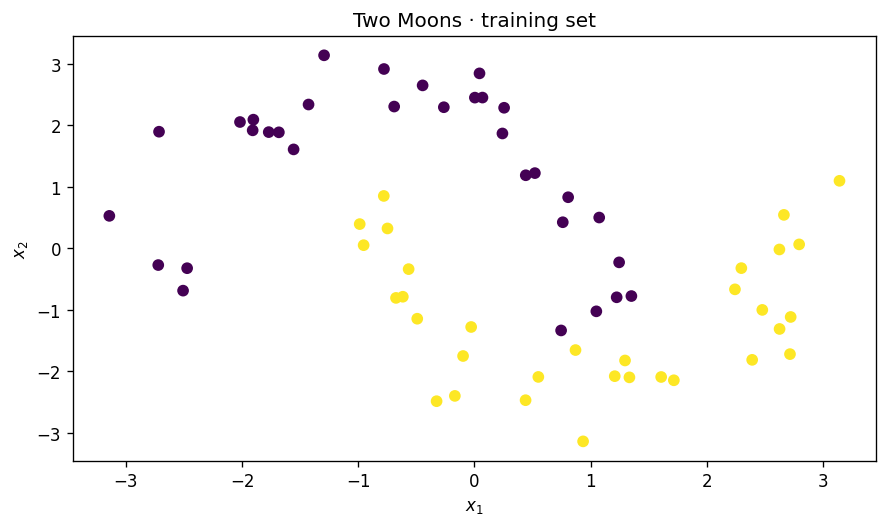

In [ ]:
plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Two Moons · training set")
plt.tight_layout()
plt.show()

## 2. Two circuits with identical architectural counts

Both models use the same encoding, ring connectivity, number of qubits, layers and trainable parameters.

- **VQC A:** \(R_y\) followed by \(R_z\)
- **VQC B:** \(R_y\) followed by \(R_y\)

In [ ]:
@dataclass(frozen=True)
class VQCModel:
    name: str
    circuit: QuantumCircuit
    x_params: tuple[Parameter, ...]
    theta_params: tuple[Parameter, ...]
    parameter_order: tuple[Parameter, ...]

    @property
    def n_parameters(self) -> int:
        return len(self.theta_params)

    @property
    def parameter_index(self) -> dict[Parameter, int]:
        return {
            parameter: index
            for index, parameter in enumerate(self.parameter_order)
        }


@dataclass
class TrainingRun:
    seed: int
    model_name: str
    history: pd.DataFrame
    checkpoints: np.ndarray


def add_encoding(
    circuit: QuantumCircuit,
    x: Sequence[Parameter],
) -> None:
    circuit.ry(x[0], 0)
    circuit.ry(x[1], 1)
    circuit.ry(0.5 * (x[0] + x[1]), 2)


def add_ring_entanglement(circuit: QuantumCircuit) -> None:
    for qubit in range(N_QUBITS):
        circuit.cz(qubit, (qubit + 1) % N_QUBITS)


def build_vqc(name: str, second_axis: str) -> VQCModel:
    x = ParameterVector(f"x_{name}", 2)
    theta = ParameterVector(
        f"theta_{name}",
        2 * N_QUBITS * N_LAYERS,
    )
    circuit = QuantumCircuit(N_QUBITS, name=name)

    cursor = 0
    for _ in range(N_LAYERS):
        add_encoding(circuit, x)
        add_ring_entanglement(circuit)

        for qubit in range(N_QUBITS):
            circuit.ry(theta[cursor], qubit)
            cursor += 1

        add_ring_entanglement(circuit)

        for qubit in range(N_QUBITS):
            getattr(circuit, second_axis)(theta[cursor], qubit)
            cursor += 1

    return VQCModel(
        name=name,
        circuit=circuit,
        x_params=tuple(x),
        theta_params=tuple(theta),
        parameter_order=tuple(circuit.parameters),
    )


model_a = build_vqc("A_RY_RZ", second_axis="rz")
model_b = build_vqc("B_RY_RY", second_axis="ry")
models = (model_a, model_b)

In [ ]:
architecture = pd.DataFrame(
    {
        model.name: {
            "Qubits": model.circuit.num_qubits,
            "Trainable parameters": model.n_parameters,
            "Circuit depth": model.circuit.depth(),
            "Circuit size": model.circuit.size(),
        }
        for model in models
    }
).T

display(architecture)

assert architecture.nunique().eq(1).all(), (
    "The two circuits must have identical architectural counts."
)

,Qubits,Trainable parameters,Circuit depth,Circuit size
A_RY_RZ,3,12,18,30
B_RY_RY,3,12,18,30


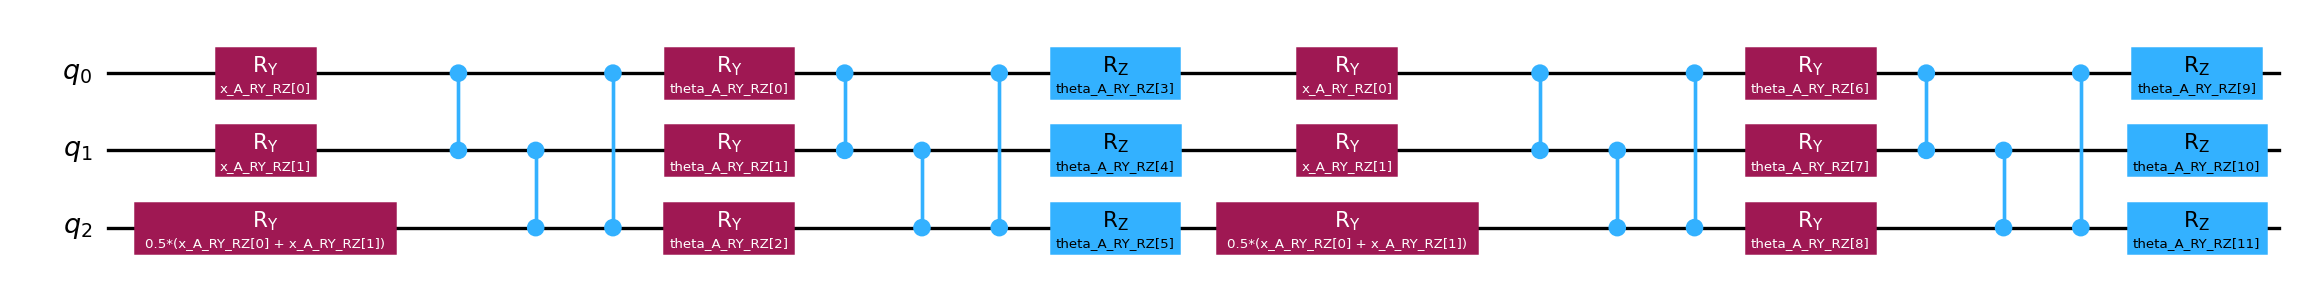

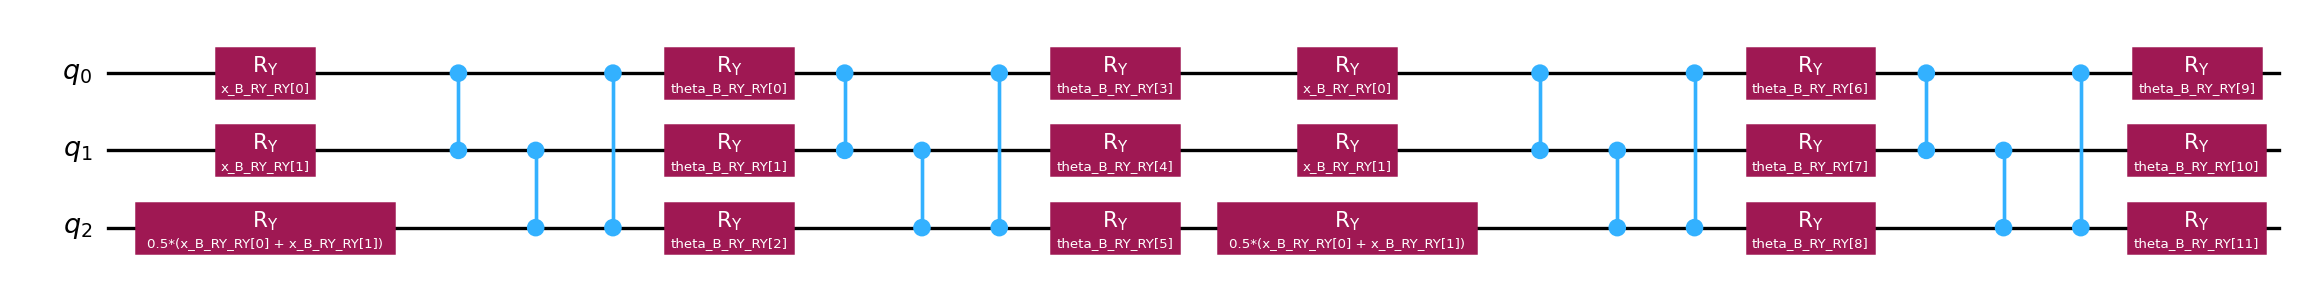

In [ ]:
display(model_a.circuit.draw("mpl", style="iqp", fold=-1))
display(model_b.circuit.draw("mpl", style="iqp", fold=-1))

## 3. Exact expectation values and parameter-shift gradients

In [ ]:
estimator = StatevectorEstimator()
observable = SparsePauliOp.from_list(
    [("I" * (N_QUBITS - 1) + "Z", 1.0)]
)


def parameter_values(
    model: VQCModel,
    X: np.ndarray,
    theta_sets: np.ndarray,
) -> np.ndarray:
    theta_sets = np.atleast_2d(theta_sets).astype(float)
    n_sets, n_samples = len(theta_sets), len(X)

    values = np.zeros(
        (n_sets * n_samples, len(model.parameter_order)),
        dtype=float,
    )
    tiled_X = np.tile(X, (n_sets, 1))

    for index, parameter in enumerate(model.theta_params):
        values[:, model.parameter_index[parameter]] = np.repeat(
            theta_sets[:, index],
            n_samples,
        )

    for index, parameter in enumerate(model.x_params):
        values[:, model.parameter_index[parameter]] = tiled_X[:, index]

    return values


def expectation_grid(
    model: VQCModel,
    X: np.ndarray,
    theta_sets: np.ndarray,
) -> np.ndarray:
    theta_sets = np.atleast_2d(theta_sets)
    values = parameter_values(model, X, theta_sets)

    result = estimator.run(
        [(model.circuit, observable, values)]
    ).result()[0]

    return np.asarray(result.data.evs, dtype=float).reshape(
        len(theta_sets),
        len(X),
    )


def probabilities_from_expectation(
    expectation: np.ndarray,
) -> np.ndarray:
    return np.clip(0.5 * (1.0 - expectation), 0.0, 1.0)


def evaluate(
    model: VQCModel,
    theta: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
) -> dict[str, float]:
    expectation = expectation_grid(model, X, theta)[0]
    probabilities = probabilities_from_expectation(expectation)

    return {
        "loss": float(np.mean((probabilities - y) ** 2)),
        "accuracy": float(
            np.mean((probabilities >= 0.5) == y)
        ),
    }


def objective_and_gradient(
    model: VQCModel,
    theta: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
) -> tuple[float, np.ndarray, np.ndarray]:
    shift = 0.5 * np.pi
    identity = np.eye(model.n_parameters)

    theta_sets = np.vstack(
        [
            theta,
            theta + shift * identity,
            theta - shift * identity,
        ]
    )

    expectation = expectation_grid(model, X, theta_sets)
    probabilities = probabilities_from_expectation(expectation[0])

    d_probabilities = -0.25 * (
        expectation[1 : 1 + model.n_parameters]
        - expectation[1 + model.n_parameters :]
    )

    residual = probabilities - y
    loss = np.mean(residual**2)
    gradient = 2.0 * np.mean(
        residual[None, :] * d_probabilities,
        axis=1,
    )

    return float(loss), gradient, probabilities

## 4. Repeated training with shared initial parameters

In [ ]:
def train_model(
    model: VQCModel,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    *,
    seed: int,
    initial_theta: np.ndarray,
    steps: int,
    learning_rate: float,
) -> TrainingRun:
    theta = initial_theta.copy()
    first_moment = np.zeros_like(theta)
    second_moment = np.zeros_like(theta)

    checkpoints = []
    records = []

    loss, gradient, probabilities = objective_and_gradient(
        model,
        theta,
        X_train,
        y_train,
    )

    for step in range(steps + 1):
        if step > 0:
            first_moment = (
                0.9 * first_moment + 0.1 * gradient
            )
            second_moment = (
                0.999 * second_moment + 0.001 * gradient**2
            )

            corrected_moment = first_moment / (1.0 - 0.9**step)
            corrected_second = (
                second_moment / (1.0 - 0.999**step)
            )

            theta -= learning_rate * corrected_moment / (
                np.sqrt(corrected_second) + 1e-8
            )

            loss, gradient, probabilities = objective_and_gradient(
                model,
                theta,
                X_train,
                y_train,
            )

        validation = evaluate(
            model,
            theta,
            X_val,
            y_val,
        )

        checkpoints.append(theta.copy())
        records.append(
            {
                "step": step,
                "train_loss": loss,
                "train_accuracy": np.mean(
                    (probabilities >= 0.5) == y_train
                ),
                "val_loss": validation["loss"],
                "val_accuracy": validation["accuracy"],
                "gradient_rms": np.sqrt(
                    np.mean(gradient**2)
                ),
            }
        )

    return TrainingRun(
        seed=seed,
        model_name=model.name,
        history=pd.DataFrame(records),
        checkpoints=np.asarray(checkpoints),
    )


runs: dict[tuple[int, str], TrainingRun] = {}

for seed in INITIALIZATION_SEEDS:
    initial_theta = np.random.default_rng(seed).normal(
        0.0,
        0.15,
        model_a.n_parameters,
    )

    for model in models:
        run = train_model(
            model,
            X_train,
            y_train,
            X_val,
            y_val,
            seed=seed,
            initial_theta=initial_theta,
            steps=STEPS,
            learning_rate=LEARNING_RATE,
        )
        runs[(seed, model.name)] = run

        final_row = run.history.iloc[-1]
        print(
            f"seed {seed:3d} · {model.name:8s} · "
            f"val loss {final_row['val_loss']:.4f} · "
            f"val accuracy {final_row['val_accuracy']:.3f} · "
            f"grad RMS {final_row['gradient_rms']:.4f}"
        )

seed  21 · A_RY_RZ  · val loss 0.1551 · val accuracy 0.750 · grad RMS 0.0053
seed  21 · B_RY_RY  · val loss 0.1141 · val accuracy 1.000 · grad RMS 0.0200
seed  34 · A_RY_RZ  · val loss 0.1563 · val accuracy 0.875 · grad RMS 0.0120
seed  34 · B_RY_RY  · val loss 0.0832 · val accuracy 0.938 · grad RMS 0.0057
seed  55 · A_RY_RZ  · val loss 0.1563 · val accuracy 0.750 · grad RMS 0.0076
seed  55 · B_RY_RY  · val loss 0.0870 · val accuracy 0.938 · grad RMS 0.0131
seed  89 · A_RY_RZ  · val loss 0.1537 · val accuracy 0.875 · grad RMS 0.0144
seed  89 · B_RY_RY  · val loss 0.0878 · val accuracy 0.875 · grad RMS 0.0041
seed 144 · A_RY_RZ  · val loss 0.1551 · val accuracy 0.750 · grad RMS 0.0064
seed 144 · B_RY_RY  · val loss 0.2247 · val accuracy 0.625 · grad RMS 0.0169


## 5. Validation-matched checkpoints

For each initialization, both models are compared at the **same optimization step**.  
The selected step minimizes their validation-performance gap after a short burn-in period.  
Test data are not used for checkpoint selection.

In [ ]:
def select_matched_step(
    run_a: TrainingRun,
    run_b: TrainingRun,
) -> dict[str, float]:
    left = run_a.history.add_suffix("_a")
    right = run_b.history.add_suffix("_b")
    comparison = pd.concat([left, right], axis=1)

    comparison["step"] = comparison["step_a"].astype(int)
    comparison["mean_val_accuracy"] = 0.5 * (
        comparison["val_accuracy_a"]
        + comparison["val_accuracy_b"]
    )
    comparison["accuracy_gap"] = np.abs(
        comparison["val_accuracy_a"]
        - comparison["val_accuracy_b"]
    )
    comparison["loss_gap"] = np.abs(
        comparison["val_loss_a"]
        - comparison["val_loss_b"]
    )
    comparison["match_score"] = (
        comparison["accuracy_gap"]
        + LOSS_GAP_WEIGHT * comparison["loss_gap"]
    )

    eligible = comparison[
        (comparison["step"] >= MIN_MATCH_STEP)
        & (
            comparison["mean_val_accuracy"]
            >= MIN_MATCH_ACCURACY
        )
    ]

    if eligible.empty:
        eligible = comparison[
            comparison["step"] >= MIN_MATCH_STEP
        ]

    best = eligible.sort_values(
        ["match_score", "step"],
        ascending=[True, False],
    ).iloc[0]

    return {
        "seed": run_a.seed,
        "matched_step": int(best["step"]),
        "val_accuracy_a": best["val_accuracy_a"],
        "val_accuracy_b": best["val_accuracy_b"],
        "val_loss_a": best["val_loss_a"],
        "val_loss_b": best["val_loss_b"],
        "accuracy_gap": best["accuracy_gap"],
        "loss_gap": best["loss_gap"],
        "match_score": best["match_score"],
    }


matched_steps = pd.DataFrame(
    [
        select_matched_step(
            runs[(seed, model_a.name)],
            runs[(seed, model_b.name)],
        )
        for seed in INITIALIZATION_SEEDS
    ]
)

display(
    matched_steps.style.format(
        {
            "val_accuracy_a": "{:.3f}",
            "val_accuracy_b": "{:.3f}",
            "val_loss_a": "{:.4f}",
            "val_loss_b": "{:.4f}",
            "accuracy_gap": "{:.3f}",
            "loss_gap": "{:.4f}",
            "match_score": "{:.4f}",
        }
    )
)

,seed,matched_step,val_accuracy_a,val_accuracy_b,val_loss_a,val_loss_b,accuracy_gap,loss_gap,match_score
0,21,25,0.812,0.812,0.1740,0.1424,0.000,0.0316,0.0632
1,34,22,0.812,0.875,0.1769,0.1072,0.062,0.0697,0.2018
2,55,13,0.688,0.688,0.2390,0.2245,0.000,0.0145,0.0291
3,89,19,0.938,0.938,0.1669,0.1079,0.000,0.0590,0.1181
4,144,16,0.688,0.688,0.1964,0.1954,0.000,0.0010,0.0020


## 6. Metrics recomputed at exactly the selected checkpoints

In [ ]:
def metrics_at_checkpoint(
    model: VQCModel,
    theta: np.ndarray,
    seed: int,
    checkpoint: str,
    step: int,
) -> dict[str, float | int | str]:
    train_loss, gradient, train_probabilities = (
        objective_and_gradient(
            model,
            theta,
            X_train,
            y_train,
        )
    )
    validation = evaluate(
        model,
        theta,
        X_val,
        y_val,
    )
    test = evaluate(
        model,
        theta,
        X_test,
        y_test,
    )

    return {
        "Seed": seed,
        "Model": model.name,
        "Checkpoint": checkpoint,
        "Step": step,
        "Train loss": train_loss,
        "Train accuracy": float(
            np.mean(
                (train_probabilities >= 0.5) == y_train
            )
        ),
        "Validation loss": validation["loss"],
        "Validation accuracy": validation["accuracy"],
        "Test loss": test["loss"],
        "Test accuracy": test["accuracy"],
        "Gradient RMS": float(
            np.sqrt(np.mean(gradient**2))
        ),
    }


matched_records = []
final_records = []

for row in matched_steps.itertuples(index=False):
    seed = int(row.seed)
    matched_step = int(row.matched_step)

    for model in models:
        run = runs[(seed, model.name)]

        matched_records.append(
            metrics_at_checkpoint(
                model,
                run.checkpoints[matched_step],
                seed,
                "Matched",
                matched_step,
            )
        )

        final_records.append(
            metrics_at_checkpoint(
                model,
                run.checkpoints[STEPS],
                seed,
                "Final",
                STEPS,
            )
        )

matched_metrics = pd.DataFrame(matched_records)
final_metrics = pd.DataFrame(final_records)


def summarize(
    frame: pd.DataFrame,
    metrics: Sequence[str],
) -> pd.DataFrame:
    rows = []

    for model_name, group in frame.groupby("Model"):
        row = {"Model": model_name}

        for metric in metrics:
            row[metric] = (
                f"{group[metric].mean():.4f} "
                f"± {group[metric].std(ddof=1):.4f}"
            )

        rows.append(row)

    return pd.DataFrame(rows).set_index("Model")


summary_columns = (
    "Train loss",
    "Train accuracy",
    "Validation loss",
    "Validation accuracy",
    "Test loss",
    "Test accuracy",
    "Gradient RMS",
)

print("Validation-matched checkpoints · mean ± standard deviation")
display(summarize(matched_metrics, summary_columns))

print("Final checkpoints · mean ± standard deviation")
display(summarize(final_metrics, summary_columns))

Validation-matched checkpoints · mean ± standard deviation


,Train loss,Train accuracy,Validation loss,Validation accuracy,Test loss,Test accuracy,Gradient RMS
Model,,,,,,,
A_RY_RZ,0.1841 ± 0.0239,0.7625 ± 0.0676,0.1906 ± 0.0292,0.7875 ± 0.1046,0.1791 ± 0.0309,0.8000 ± 0.0523,0.0164 ± 0.0046
B_RY_RY,0.0988 ± 0.0274,0.9156 ± 0.0422,0.1555 ± 0.0527,0.8000 ± 0.1118,0.1388 ± 0.0512,0.8250 ± 0.1118,0.0271 ± 0.0058


Final checkpoints · mean ± standard deviation


,Train loss,Train accuracy,Validation loss,Validation accuracy,Test loss,Test accuracy,Gradient RMS
Model,,,,,,,
A_RY_RZ,0.1472 ± 0.0063,0.7656 ± 0.0191,0.1553 ± 0.0011,0.8000 ± 0.0685,0.1336 ± 0.0047,0.8250 ± 0.0280,0.0091 ± 0.0039
B_RY_RY,0.0681 ± 0.0217,0.9688 ± 0.0456,0.1194 ± 0.0601,0.8750 ± 0.1466,0.0936 ± 0.0388,0.9375 ± 0.1083,0.0120 ± 0.0069


In [ ]:
matched_pairwise = (
    matched_metrics.pivot(
        index="Seed",
        columns="Model",
        values=[
            "Validation accuracy",
            "Test accuracy",
            "Gradient RMS",
        ],
    )
)

pairwise_summary = pd.DataFrame(
    {
        "Validation accuracy gap": np.abs(
            matched_pairwise[
                ("Validation accuracy", model_a.name)
            ]
            - matched_pairwise[
                ("Validation accuracy", model_b.name)
            ]
        ),
        "Test accuracy gap": np.abs(
            matched_pairwise[
                ("Test accuracy", model_a.name)
            ]
            - matched_pairwise[
                ("Test accuracy", model_b.name)
            ]
        ),
        "Gradient RMS ratio B/A": (
            matched_pairwise[
                ("Gradient RMS", model_b.name)
            ]
            / matched_pairwise[
                ("Gradient RMS", model_a.name)
            ].clip(lower=1e-12)
        ),
    }
)

display(pairwise_summary.style.format("{:.4f}"))
print(
    "Mean validation accuracy gap:",
    f"{pairwise_summary['Validation accuracy gap'].mean():.4f}",
)
print(
    "Mean test accuracy gap:",
    f"{pairwise_summary['Test accuracy gap'].mean():.4f}",
)

,Validation accuracy gap,Test accuracy gap,Gradient RMS ratio B/A
Seed,,,
21,0.0000,0.0000,2.4087
34,0.0625,0.0625,2.2137
55,0.0000,0.0625,1.4235
89,0.0000,0.1250,2.0695
144,0.0000,0.0000,0.8360


Mean validation accuracy gap: 0.0125
Mean test accuracy gap: 0.0500


## 7. A representative run for the training curves

In [ ]:
median_score = matched_steps["match_score"].median()
representative_row = matched_steps.iloc[
    (matched_steps["match_score"] - median_score)
    .abs()
    .argsort()
    .iloc[0]
]

REPRESENTATIVE_SEED = int(representative_row["seed"])
REPRESENTATIVE_STEP = int(
    representative_row["matched_step"]
)

print("Representative seed:", REPRESENTATIVE_SEED)
print("Matched step:", REPRESENTATIVE_STEP)

Representative seed: 21
Matched step: 25


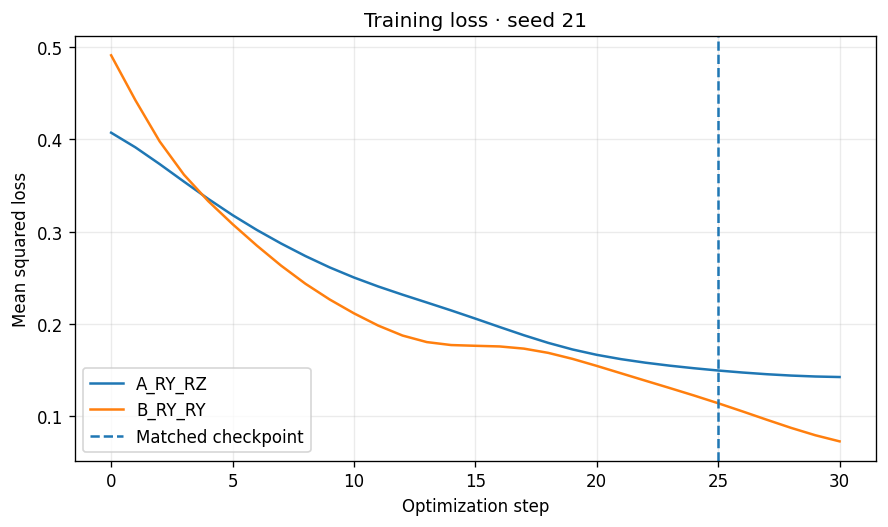

In [ ]:
plt.figure()
for model in models:
    history = runs[
        (REPRESENTATIVE_SEED, model.name)
    ].history

    plt.plot(
        history["step"],
        history["train_loss"],
        label=model.name,
    )

plt.axvline(
    REPRESENTATIVE_STEP,
    linestyle="--",
    label="Matched checkpoint",
)
plt.xlabel("Optimization step")
plt.ylabel("Mean squared loss")
plt.title(
    f"Training loss · seed {REPRESENTATIVE_SEED}"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

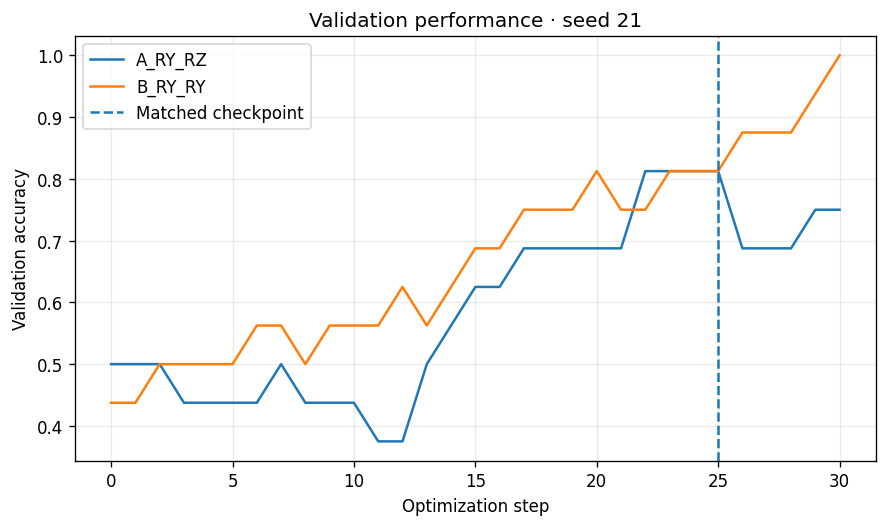

In [ ]:
plt.figure()
for model in models:
    history = runs[
        (REPRESENTATIVE_SEED, model.name)
    ].history

    plt.plot(
        history["step"],
        history["val_accuracy"],
        label=model.name,
    )

plt.axvline(
    REPRESENTATIVE_STEP,
    linestyle="--",
    label="Matched checkpoint",
)
plt.xlabel("Optimization step")
plt.ylabel("Validation accuracy")
plt.title(
    f"Validation performance · seed {REPRESENTATIVE_SEED}"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

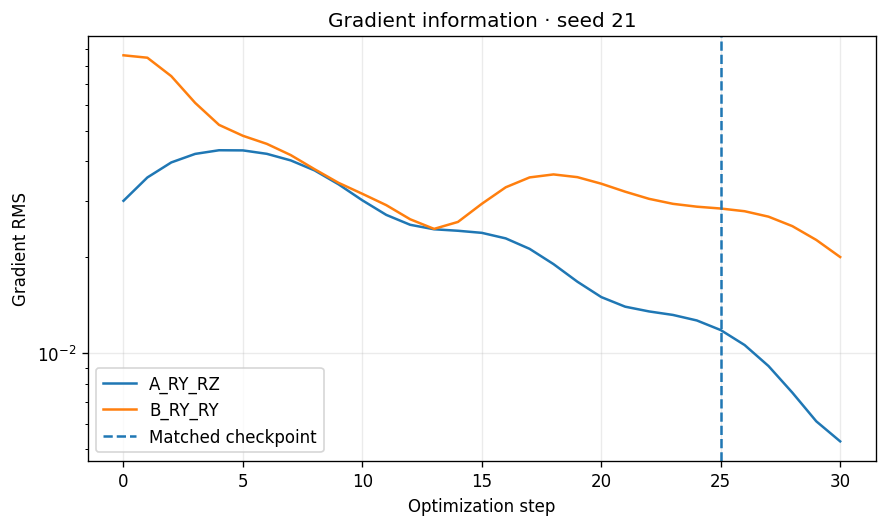

In [ ]:
plt.figure()
for model in models:
    history = runs[
        (REPRESENTATIVE_SEED, model.name)
    ].history

    plt.plot(
        history["step"],
        history["gradient_rms"],
        label=model.name,
    )

plt.axvline(
    REPRESENTATIVE_STEP,
    linestyle="--",
    label="Matched checkpoint",
)
plt.xlabel("Optimization step")
plt.ylabel("Gradient RMS")
plt.title(
    f"Gradient information · seed {REPRESENTATIVE_SEED}"
)
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Geometry of the matched representations

For each test sample, the selected VQC produces a state \(\lvert\psi(x)\rangle\).  
The fidelity kernel

\[
K_{ij}=\left|\langle\psi(x_i)\mid\psi(x_j)\rangle\right|^2
\]

provides a compact view of the induced representation geometry.

In [ ]:
def statevectors(
    model: VQCModel,
    X: np.ndarray,
    theta: np.ndarray,
) -> np.ndarray:
    theta_binding = dict(
        zip(model.theta_params, theta)
    )
    vectors = []

    for sample in X:
        binding = theta_binding | dict(
            zip(model.x_params, sample)
        )
        circuit = model.circuit.assign_parameters(binding)
        vectors.append(
            Statevector.from_instruction(circuit).data
        )

    return np.asarray(vectors)


def fidelity_kernel(states: np.ndarray) -> np.ndarray:
    overlaps = states.conj() @ states.T
    return np.abs(overlaps) ** 2


def centered_kernel_alignment(
    kernel: np.ndarray,
    labels: np.ndarray,
) -> float:
    n_samples = len(labels)
    centering = (
        np.eye(n_samples)
        - np.ones((n_samples, n_samples)) / n_samples
    )

    centered_kernel = centering @ kernel @ centering
    target = np.outer(
        2 * labels - 1,
        2 * labels - 1,
    )
    centered_target = centering @ target @ centering

    numerator = np.sum(
        centered_kernel * centered_target
    )
    denominator = (
        np.linalg.norm(centered_kernel)
        * np.linalg.norm(centered_target)
    )

    return float(numerator / denominator)


def effective_rank(kernel: np.ndarray) -> float:
    eigenvalues = np.linalg.eigvalsh(kernel)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    probabilities = eigenvalues / eigenvalues.sum()
    probabilities = probabilities[
        probabilities > 1e-12
    ]

    return float(
        np.exp(
            -np.sum(
                probabilities * np.log(probabilities)
            )
        )
    )


order = np.argsort(y_test)
X_kernel = X_test[order]
y_kernel = y_test[order]

kernel_records = []
kernels_by_seed = {}

for row in matched_steps.itertuples(index=False):
    seed = int(row.seed)
    step = int(row.matched_step)
    pair = {}

    for model in models:
        theta = runs[
            (seed, model.name)
        ].checkpoints[step]

        states = statevectors(
            model,
            X_kernel,
            theta,
        )
        kernel = fidelity_kernel(states)
        pair[model.name] = kernel

        kernel_records.append(
            {
                "Seed": seed,
                "Model": model.name,
                "Centered alignment": (
                    centered_kernel_alignment(
                        kernel,
                        y_kernel,
                    )
                ),
                "Effective rank": effective_rank(kernel),
            }
        )

    kernels_by_seed[seed] = pair

kernel_metrics = pd.DataFrame(kernel_records)

kernel_distances = pd.DataFrame(
    {
        "Seed": INITIALIZATION_SEEDS,
        "Relative kernel distance": [
            np.linalg.norm(
                kernels_by_seed[seed][model_a.name]
                - kernels_by_seed[seed][model_b.name],
                ord="fro",
            )
            / np.linalg.norm(
                kernels_by_seed[seed][model_a.name],
                ord="fro",
            )
            for seed in INITIALIZATION_SEEDS
        ],
    }
)

display(
    summarize(
        kernel_metrics,
        ("Centered alignment", "Effective rank"),
    )
)
display(
    kernel_distances.style.format(
        {"Relative kernel distance": "{:.4f}"}
    )
)
print(
    "Mean relative kernel distance:",
    f"{kernel_distances['Relative kernel distance'].mean():.4f}",
)

,Centered alignment,Effective rank
Model,,
A_RY_RZ,0.3741 ± 0.1013,9.3721 ± 0.5333
B_RY_RY,0.3403 ± 0.0544,11.1728 ± 0.4854


,Seed,Relative kernel distance
0,21,0.4685
1,34,0.3517
2,55,0.4349
3,89,0.4339
4,144,0.5512


Mean relative kernel distance: 0.4480


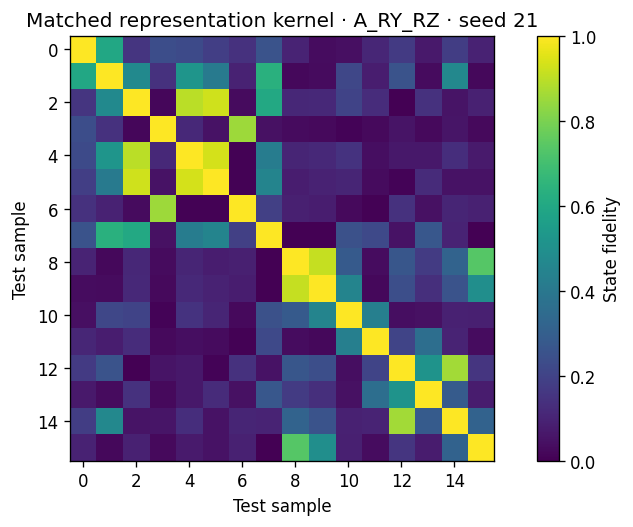

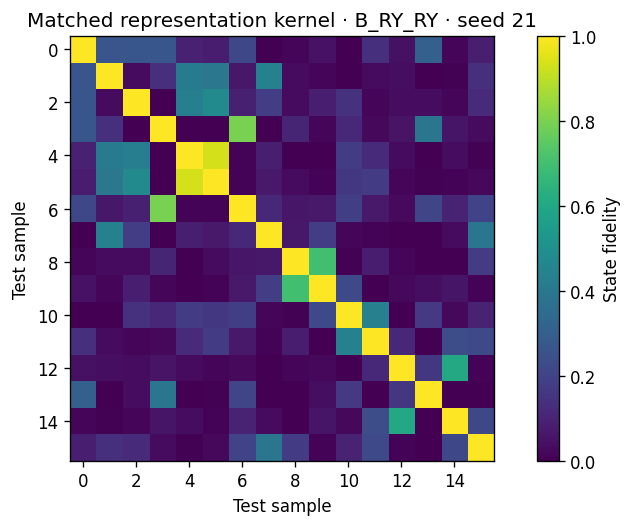

In [ ]:
representative_kernels = kernels_by_seed[
    REPRESENTATIVE_SEED
]

for model in models:
    plt.figure()
    plt.imshow(
        representative_kernels[model.name],
        vmin=0.0,
        vmax=1.0,
    )
    plt.colorbar(label="State fidelity")
    plt.xlabel("Test sample")
    plt.ylabel("Test sample")
    plt.title(
        "Matched representation kernel · "
        f"{model.name} · seed {REPRESENTATIVE_SEED}"
    )
    plt.tight_layout()
    plt.show()

## Open question

The circuits have identical visible architectural counts and are compared at checkpoints selected to have similar validation performance. Their gradient signals and fidelity kernels may nevertheless differ.

This does **not** establish that they have learned different concepts. It tests a narrower claim:

> **Final performance alone may be insufficient to characterize the learning process of a VQC.**

The next step is to determine whether these differences remain stable under more seeds, noise, alternative observables and explicit structural analysis.